In [8]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLORS = sns.color_palette('muted')

PLOT_DIR = Path('results/plots')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv('results/llm_judge_results.csv')

criteria = ['Relevance', 'Visual_Quality', 'Coherence', 'Aesthetics']
labels   = ['Relevance', 'Visual Quality', 'Coherence', 'Aesthetics']

df.head(3)

,query_id,query,Relevance,Visual_Quality,Coherence,Aesthetics,mean_score,n_images,n_retrieved,n_generated,routing_decision,top_hybrid_score,board_summary_len,reasoning,error
0,1,feeling burnt out after a long week,5,2,4,2,3.25,9,0,9,generation,0.3716,755,The board is conceptually excellent—every imag...,NaN
1,2,celebrating a new job offer,4,3,3,3,3.25,9,2,7,retrieval,0.4054,643,The board successfully captures the job celebr...,NaN
2,3,quiet sunday morning with coffee,4,4,2,3,3.25,9,9,0,retrieval,0.5975,647,The first 7 images directly capture the coffee...,NaN


## Mean LLM-Judge Score per Criterion (out of 5)

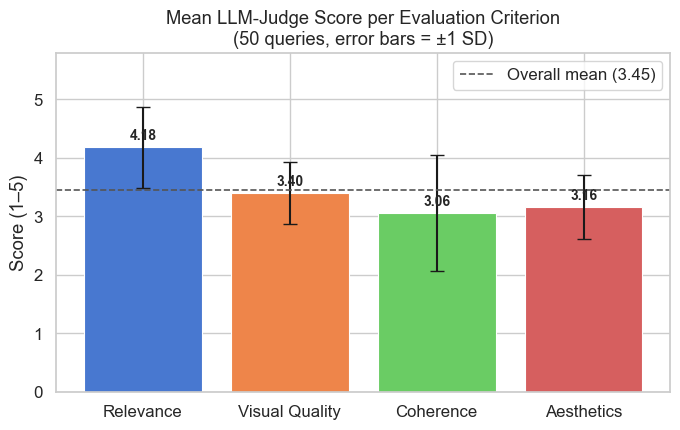

In [9]:
means   = [df[c].mean() for c in criteria]
stds    = [df[c].std()  for c in criteria]
overall = df['mean_score'].mean()

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(labels, means, yerr=stds, capsize=5, color=COLORS[:4], edgecolor='white', linewidth=0.8)
ax.axhline(overall, color='#555', linestyle='--', linewidth=1.2, label=f'Overall mean ({overall:.2f})')

for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, m + 0.08, f'{m:.2f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0, 5.8)
ax.set_ylabel('Score (1–5)')
ax.set_title('Mean LLM-Judge Score per Evaluation Criterion\n(50 queries, error bars = ±1 SD)')
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / 'mean_scores.png', dpi=150)
plt.show()

## Score Distributions (Strip + Box)

/var/folders/gc/drvvdqb93dqg4y0zt5zljf5w0000gn/T/ipykernel_77503/1945203917.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


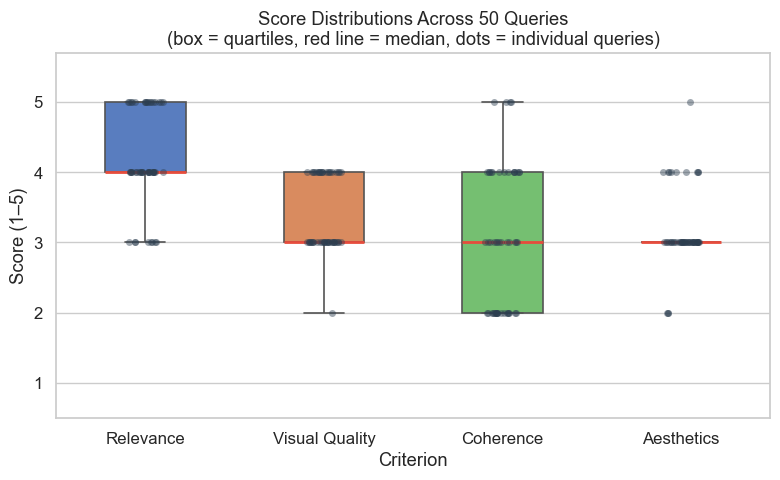

In [10]:
plot_df = df[criteria].rename(columns=dict(zip(criteria, labels)))
long_df = plot_df.melt(var_name='Criterion', value_name='Score')

fig, ax = plt.subplots(figsize=(8, 5))

# box behind the points
sns.boxplot(
    data=long_df, x='Criterion', y='Score',
    palette='muted', width=0.45, linewidth=1.2,
    fliersize=0,  # hide fliers — strip will show them
    medianprops=dict(color='#e74c3c', linewidth=2),
    ax=ax
)

# individual query points on top
sns.stripplot(
    data=long_df, x='Criterion', y='Score',
    color='#2c3e50', alpha=0.45, size=5, jitter=True,
    ax=ax
)

ax.set_ylim(0.5, 5.7)
ax.set_ylabel('Score (1–5)')
ax.set_title('Score Distributions Across 50 Queries\n(box = quartiles, red line = median, dots = individual queries)')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'score_distributions.png', dpi=150)
plt.show()

## Hybrid Retrieval Score vs. Overall LLM-Judge Score

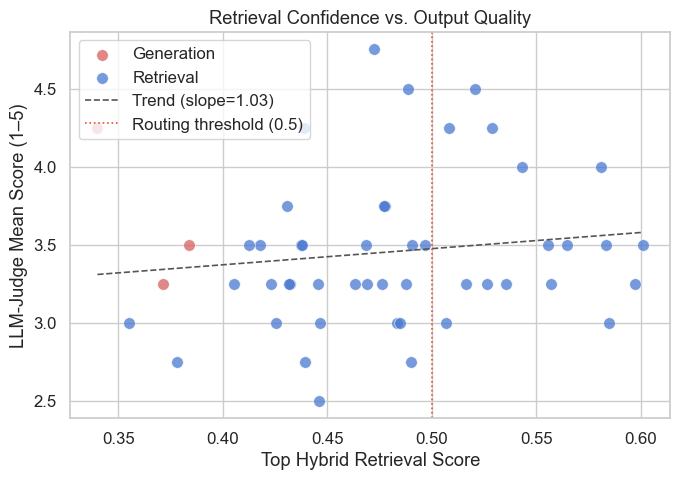

In [11]:
palette = {'retrieval': COLORS[0], 'generation': COLORS[3]}

fig, ax = plt.subplots(figsize=(7, 5))
for route, grp in df.groupby('routing_decision'):
    ax.scatter(grp['top_hybrid_score'], grp['mean_score'],
               color=palette[route], label=route.capitalize(),
               alpha=0.75, edgecolors='white', linewidths=0.5, s=70)

m, b = np.polyfit(df['top_hybrid_score'], df['mean_score'], 1)
xs = np.linspace(df['top_hybrid_score'].min(), df['top_hybrid_score'].max(), 100)
ax.plot(xs, m*xs + b, color='#555', linestyle='--', linewidth=1.2, label=f'Trend (slope={m:.2f})')
ax.axvline(0.5, color='#e74c3c', linestyle=':', linewidth=1.2, label='Routing threshold (0.5)')

ax.set_xlabel('Top Hybrid Retrieval Score')
ax.set_ylabel('LLM-Judge Mean Score (1–5)')
ax.set_title('Retrieval Confidence vs. Output Quality')
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / 'hybrid_vs_quality.png', dpi=150)
plt.show()

## Hybrid Score Distribution with Routing Threshold

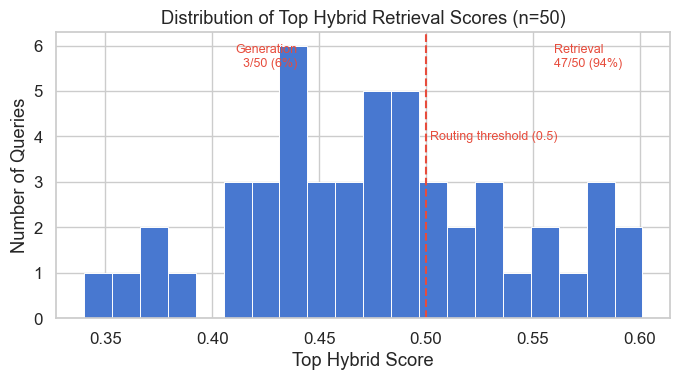

In [17]:
n_ret = (df['routing_decision'] == 'retrieval').sum()
n_gen = (df['routing_decision'] == 'generation').sum()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df['top_hybrid_score'], bins=20, color=COLORS[0], edgecolor='white', linewidth=0.7)
ax.axvline(0.5, color='#e74c3c', linestyle='--', linewidth=1.5)

ymax = ax.get_ylim()[1]
ax.text(0.502, 4, 'Routing threshold (0.5)', color='#e74c3c', fontsize=9, va='center')
ax.text(0.56, ymax * 0.88, f'Retrieval\n{n_ret}/50 (94%)', color='#e74c3c', fontsize=9)
ax.text(0.44, ymax * 0.88, f'Generation\n{n_gen}/50 (6%)',  color='#e74c3c', fontsize=9, ha='right')

ax.set_xlabel('Top Hybrid Score')
ax.set_ylabel('Number of Queries')
ax.set_title('Distribution of Top Hybrid Retrieval Scores (n=50)')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'hybrid_distribution.png', dpi=150)
plt.show()

## Top 5 and Bottom 5 Queries by Mean Score

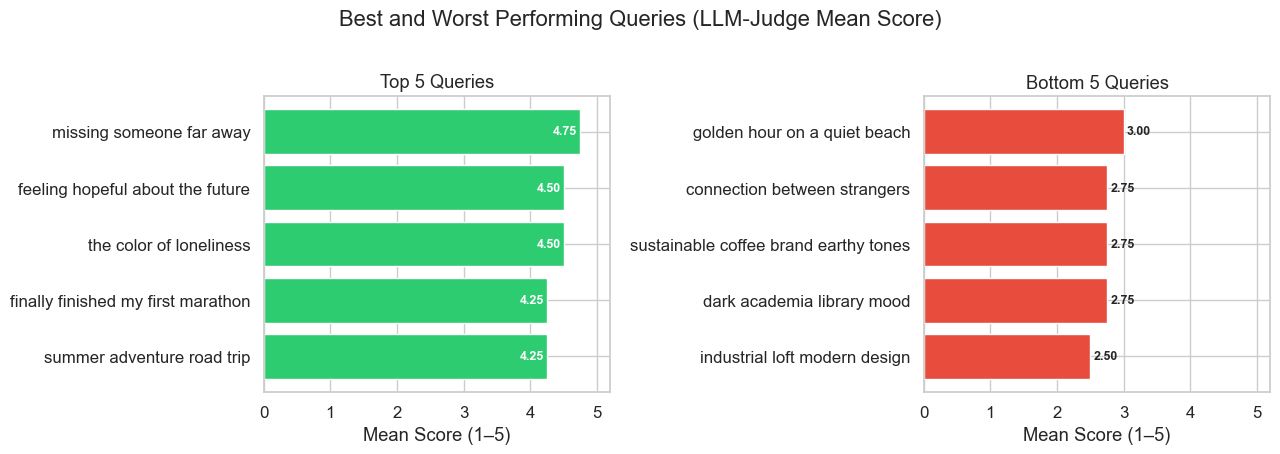

In [18]:
import textwrap

def wrap(s, width=42):
    return '\n'.join(textwrap.wrap(s, width))

top5    = df.nlargest(5,  'mean_score')[['query','mean_score']].iloc[::-1].copy()
bottom5 = df.nsmallest(5, 'mean_score')[['query','mean_score']].copy()
top5['label']    = top5['query'].apply(wrap)
bottom5['label'] = bottom5['query'].apply(wrap)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.barh(top5['label'], top5['mean_score'], color='#2ecc71', edgecolor='white')
for i, v in enumerate(top5['mean_score']):
    ax1.text(v - 0.05, i, f'{v:.2f}', va='center', ha='right', fontsize=9, color='white', fontweight='bold')
ax1.set_xlim(0, 5.2)
ax1.set_xlabel('Mean Score (1–5)')
ax1.set_title('Top 5 Queries')

ax2.barh(bottom5['label'], bottom5['mean_score'], color='#e74c3c', edgecolor='white')
for i, v in enumerate(bottom5['mean_score']):
    ax2.text(v + 0.05, i, f'{v:.2f}', va='center', ha='left', fontsize=9, fontweight='bold')
ax2.set_xlim(0, 5.2)
ax2.set_xlabel('Mean Score (1–5)')
ax2.set_title('Bottom 5 Queries')

fig.suptitle('Best and Worst Performing Queries (LLM-Judge Mean Score)', y=1.01)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'top_bottom_queries.png', dpi=150, bbox_inches='tight')
plt.show()

## Correlation Heatmap: Evaluation Criteria

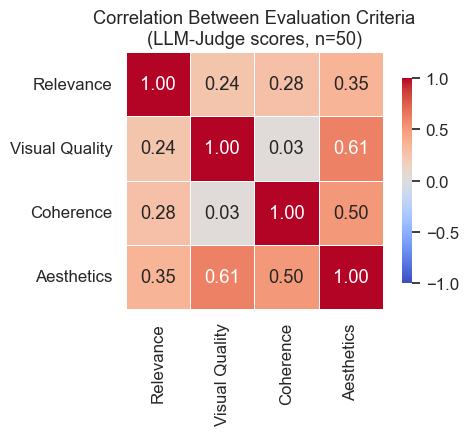

In [19]:
corr = df[criteria].rename(columns=dict(zip(criteria, labels))).corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Between Evaluation Criteria\n(LLM-Judge scores, n=50)')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'correlation_heatmap.png', dpi=150)
plt.show()